In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions

from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import torch
import torch.nn as nn
import torch.optim as optim

In [2]:
X,y=make_circles(n_samples=100,noise=0.1,random_state=1)

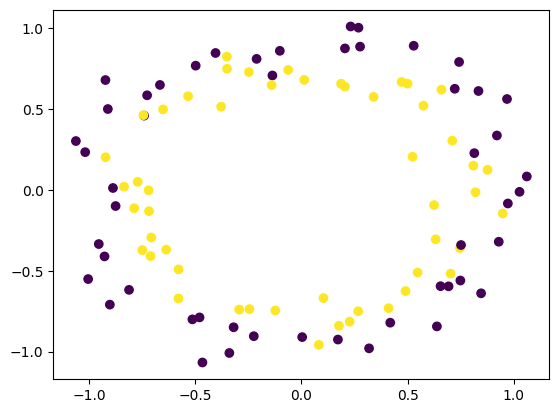

In [4]:
plt.scatter(X[:,0],X[:,1],c=y)

In [5]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)

In [11]:
X_train_tensor=torch.tensor(X_train,dtype=torch.float32)
X_test_tensor=torch.tensor(X_test,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train,dtype=torch.float32).unsqueeze(1)
y_test_tensor=torch.tensor(y_test,dtype=torch.float32).unsqueeze(1)

In [8]:
class Simplemodel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2,256),
            nn.ReLU(),
            nn.Linear(256,1),
            nn.Sigmoid()
        )
    def forward(self,x):
        return self.net(x)

In [60]:
model=Simplemodel()

In [61]:

criterion=nn.BCELoss()
optimizer=optim.Adam(model.parameters(),lr=0.01)

In [62]:
train_loss=[]
val_loss=[]

In [63]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0 ):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = np.inf
        self.early_stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

In [64]:
early_stopping = EarlyStopping(patience=20)

for epoch in range(1000):

    # -------- TRAIN --------
    model.train()
    output = model(X_train_tensor)
    loss = criterion(output, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # -------- VALIDATION --------
    model.eval()
    with torch.no_grad():
        val_output = model(X_test_tensor)
        validation_loss = criterion(val_output, y_test_tensor)

    # -------- LOGGING --------
    if epoch % 10 == 0:
        train_loss.append(loss.item())
        val_loss.append(validation_loss.item())

        print(
            f"Epoch {epoch} | "
            f"Train Loss: {loss.item():.4f} | "
            f"Val Loss: {validation_loss.item():.4f}"
        )

    # -------- EARLY STOPPING --------
    early_stopping(validation_loss.item(), model)

    if early_stopping.early_stop:
        print(f"Early stopping triggered at epoch {epoch} 🚀")
        break


Epoch 0 | Train Loss: 0.7020 | Val Loss: 0.7385
Epoch 10 | Train Loss: 0.6037 | Val Loss: 0.6527
Epoch 20 | Train Loss: 0.5046 | Val Loss: 0.5416
Epoch 30 | Train Loss: 0.4095 | Val Loss: 0.4408
Epoch 40 | Train Loss: 0.3366 | Val Loss: 0.3740
Epoch 50 | Train Loss: 0.2888 | Val Loss: 0.3446
Epoch 60 | Train Loss: 0.2598 | Val Loss: 0.3397
Epoch 70 | Train Loss: 0.2416 | Val Loss: 0.3484
Epoch 80 | Train Loss: 0.2294 | Val Loss: 0.3610
Early stopping triggered at epoch 83 🚀


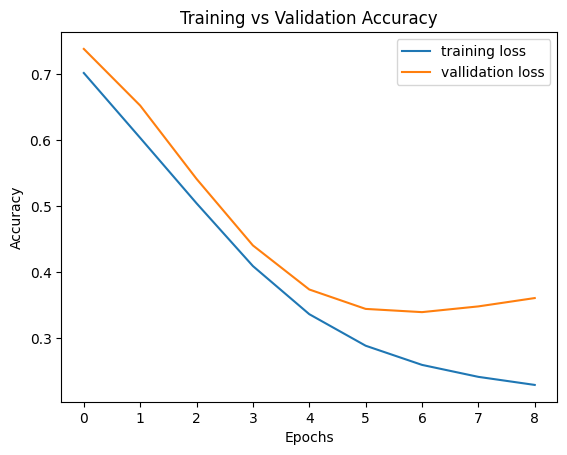

In [65]:
plt.plot(train_loss,label="training loss")
plt.plot(val_loss,label="vallidation loss")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()